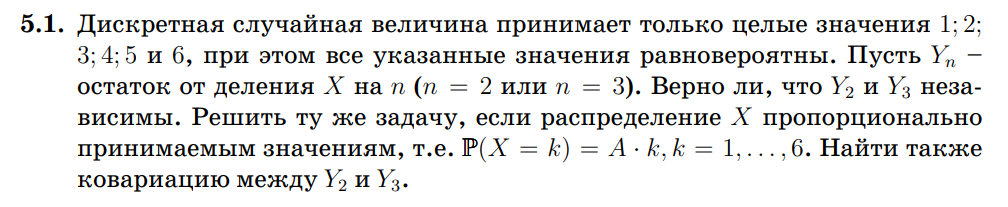

In [ ]:

import numpy as np

dist1 = {k:1/6 for k in range(1,7)}

A = 1/sum(range(1,7))
dist2 = {k:A*k for k in range(1,7)}

def cov_y2_y3(dist):
    EY2 = EY3 = EY2Y3 = 0
    for x,p in dist.items():
        y2, y3 = x%2, x%3
        EY2 += y2*p
        EY3 += y3*p
        EY2Y3 += y2*y3*p
    return EY2Y3 - EY2*EY3

cov_uniform = cov_y2_y3(dist1)
cov_weighted = cov_y2_y3(dist2)

if cov_uniform % 2 == 0:
  print("Зависимы")
else:
  print("Независимы")

print("Ковариация:", cov_weighted)

Зависимы
Ковариация: 0.13605442176870747


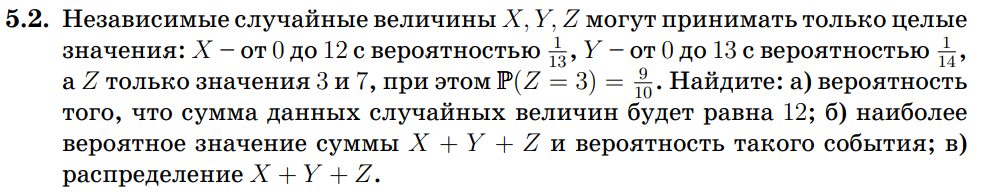

In [1]:
import collections

# Вероятности
px = {i: 1/13 for i in range(13)}          # X = 0..12
py = {i: 1/14 for i in range(14)}          # Y = 0..13
pz = {3: 0.9, 7: 0.1}                      # Z = 3 или 7

ps = collections.Counter()

for x, pxv in px.items():
    for y, pyv in py.items():
        for z, pzv in pz.items():
            s = x + y + z
            ps[s] += pxv * pyv * pzv

print("Распределение суммы S = X + Y + Z:\n")

for s in sorted(ps.keys()):
    prob = ps[s]
    percent = prob * 100
    print(f"S = {s:2d}  →  вероятность = {prob:.8f}  ≈ {percent:5.3f}%")

print()

print(f"а) P(S = 12) = {ps[12]:.8f}  ≈ {ps[12]*100:.3f}%")

max_s, max_p = max(ps.items(), key=lambda t: t[1])
print(f"б) Наиболее вероятное значение: {max_s}")
print(f"   Вероятность этого значения: {max_p:.8f}  ≈ {max_p*100:.3f}%")

Распределение суммы S = X + Y + Z:

S =  3  →  вероятность = 0.00494505  ≈ 0.495%
S =  4  →  вероятность = 0.00989011  ≈ 0.989%
S =  5  →  вероятность = 0.01483516  ≈ 1.484%
S =  6  →  вероятность = 0.01978022  ≈ 1.978%
S =  7  →  вероятность = 0.02527473  ≈ 2.527%
S =  8  →  вероятность = 0.03076923  ≈ 3.077%
S =  9  →  вероятность = 0.03626374  ≈ 3.626%
S = 10  →  вероятность = 0.04175824  ≈ 4.176%
S = 11  →  вероятность = 0.04725275  ≈ 4.725%
S = 12  →  вероятность = 0.05274725  ≈ 5.275%
S = 13  →  вероятность = 0.05824176  ≈ 5.824%
S = 14  →  вероятность = 0.06373626  ≈ 6.374%
S = 15  →  вероятность = 0.06923077  ≈ 6.923%
S = 16  →  вероятность = 0.06978022  ≈ 6.978%
S = 17  →  вероятность = 0.06538462  ≈ 6.538%
S = 18  →  вероятность = 0.06098901  ≈ 6.099%
S = 19  →  вероятность = 0.05659341  ≈ 5.659%
S = 20  →  вероятность = 0.05164835  ≈ 5.165%
S = 21  →  вероятность = 0.04615385  ≈ 4.615%
S = 22  →  вероятность = 0.04065934  ≈ 4.066%
S = 23  →  вероятность = 0.03516484  ≈ 3.516

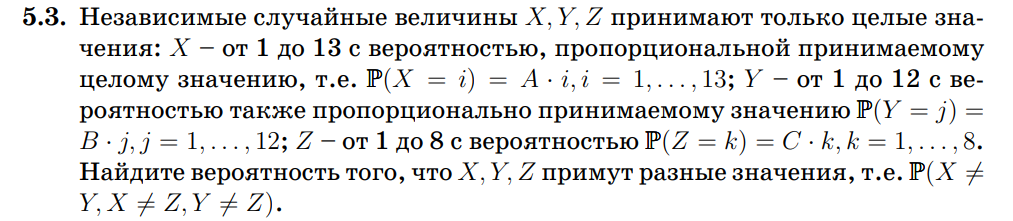

In [2]:
import itertools

Ax = 1/sum(range(1,14))
Ay = 1/sum(range(1,13))
Az = 1/sum(range(1,9))

px = {i:Ax*i for i in range(1,14)}
py = {i:Ay*i for i in range(1,13)}
pz = {i:Az*i for i in range(1,9)}

prob = 0
for x,y,z in itertools.product(px,py,pz):
    if x!=y and x!=z and y!=z:
        prob += px[x]*py[y]*pz[z]
print("Вероятность того, что X, Y, Z примут разные значения:", prob)


Вероятность того, что X, Y, Z примут разные значения: 0.783647975955668


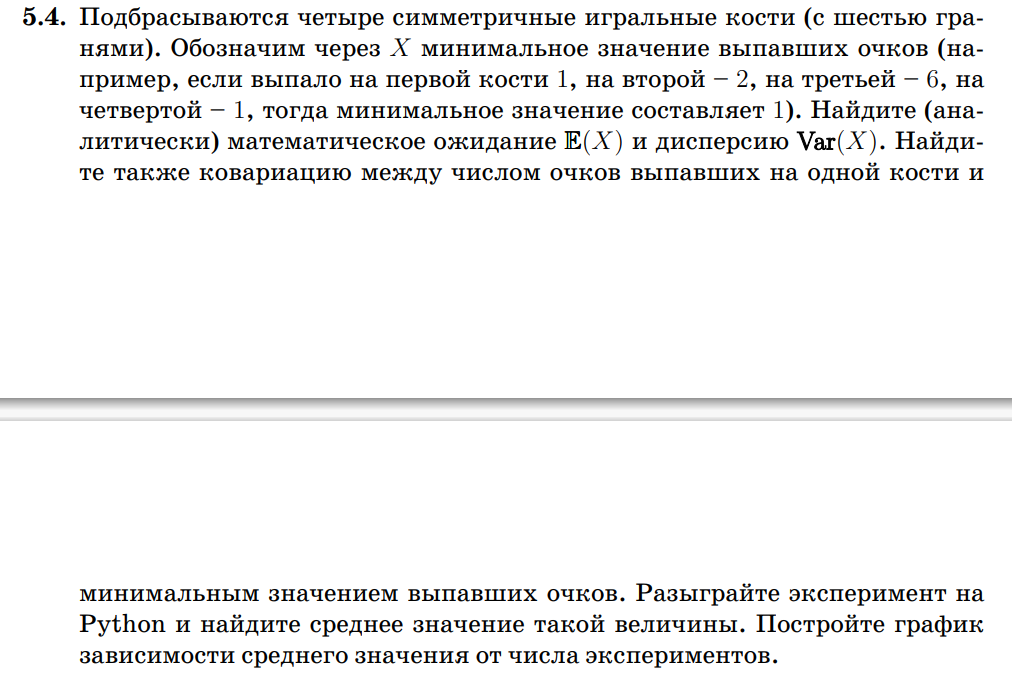

E(X)       = 1.755401
Var(X)     = 0.910079
Cov(X, D₁) = 3.982639

Распределение P(X = k):
k =  1 → 0.517747
k =  2 → 0.284722
k =  3 → 0.135031
k =  4 → 0.050154
k =  5 → 0.011574
k =  6 → 0.000772


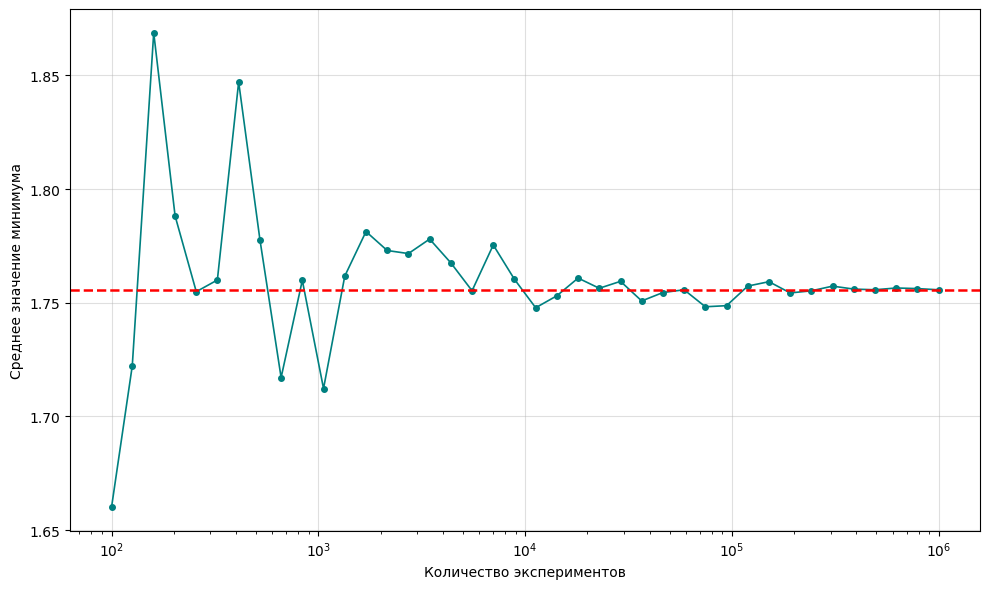

In [3]:
import numpy as np
import matplotlib.pyplot as plt

values = range(1, 7)

PX = {}
for k in values:
    p_ge_k = ((7 - k) / 6) ** 4
    p_ge_k1 = ((7 - (k + 1)) / 6) ** 4 if k < 6 else 0
    PX[k] = p_ge_k - p_ge_k1

EX = sum(k * PX[k] for k in values)
VarX = sum((k - EX)**2 * PX[k] for k in values)

E_one_die = 3.5

EXY = 0.0
for m in range(1, 7):
    for x in range(1, 7):
        if x < m:
            p = 0
        elif x == m:
            p = (1/6) * ((7 - m)/6)**3
        else:
            p_ge_m = ((7 - m)/6)**3
            p_ge_x = ((7 - x)/6)**3
            p = (1/6) * (p_ge_m - p_ge_x)
        EXY += x * m * p

Cov_X_D1 = EXY - E_one_die * EX

print("E(X)       =", round(EX, 6))
print("Var(X)     =", round(VarX, 6))
print("Cov(X, D₁) =", round(Cov_X_D1, 6))

print("\nРаспределение P(X = k):")
for k in sorted(PX):
    print(f"k = {k:2d} → {PX[k]:.6f}")

def experiment(n_trials):
    rolls = np.random.randint(1, 7, size=(n_trials, 4))
    return rolls.min(axis=1).mean()

Ns = np.logspace(2, 6, 40, dtype=int)
means = [experiment(n) for n in Ns]

plt.figure(figsize=(10, 6))
plt.plot(Ns, means, 'o-', color='teal', markersize=4, linewidth=1.2)
plt.axhline(EX, color='red', linestyle='--', linewidth=1.8)
plt.xscale('log')
plt.xlabel('Количество экспериментов')
plt.ylabel('Среднее значение минимума')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

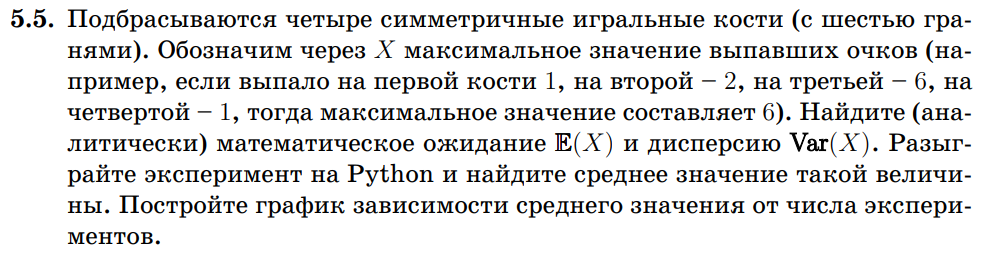

E(X)   = 5.244599
Var(X) = 0.910079

Распределение P(X = k):
k =  1 → 0.000772
k =  2 → 0.011574
k =  3 → 0.050154
k =  4 → 0.135031
k =  5 → 0.284722
k =  6 → 0.517747


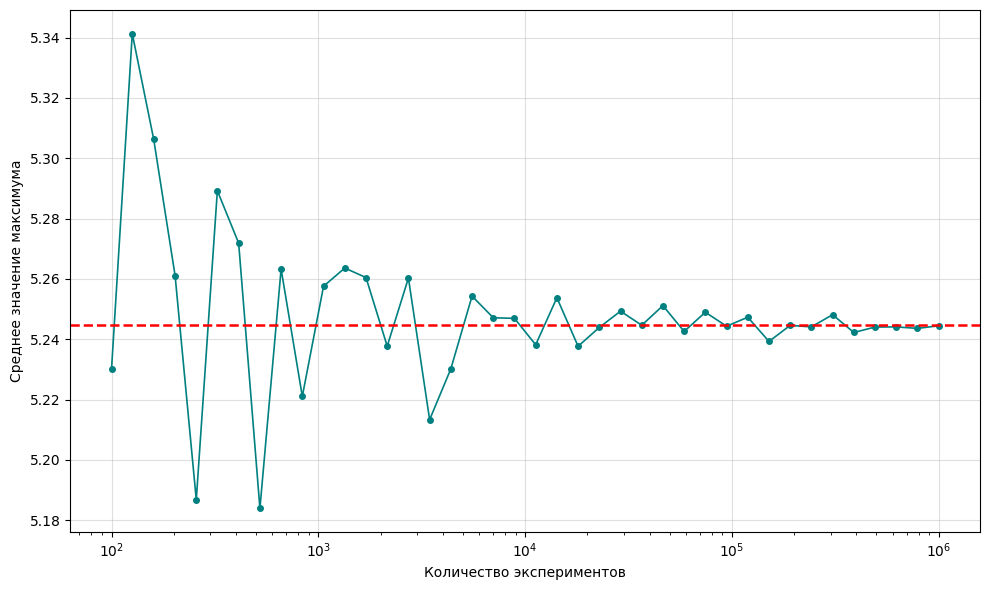

In [4]:
import numpy as np
import matplotlib.pyplot as plt

values = range(1, 7)
PX = {k: (k/6)**4 - ((k-1)/6)**4 for k in values}

EX = sum(k * PX[k] for k in values)
VarX = sum((k - EX)**2 * PX[k] for k in values)

print("E(X)   =", round(EX, 6))
print("Var(X) =", round(VarX, 6))

print("\nРаспределение P(X = k):")
for k in values:
    print(f"k = {k:2d} → {PX[k]:.6f}")

def experiment(n_trials):
    rolls = np.random.randint(1, 7, size=(n_trials, 4))
    return rolls.max(axis=1).mean()

Ns = np.logspace(2, 6, 40, dtype=int)
means = [experiment(n) for n in Ns]

plt.figure(figsize=(10, 6))
plt.plot(Ns, means, 'o-', color='teal', markersize=4, linewidth=1.2)
plt.axhline(EX, color='red', linestyle='--', linewidth=1.8)
plt.xscale('log')
plt.xlabel('Количество экспериментов')
plt.ylabel('Среднее значение максимума')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

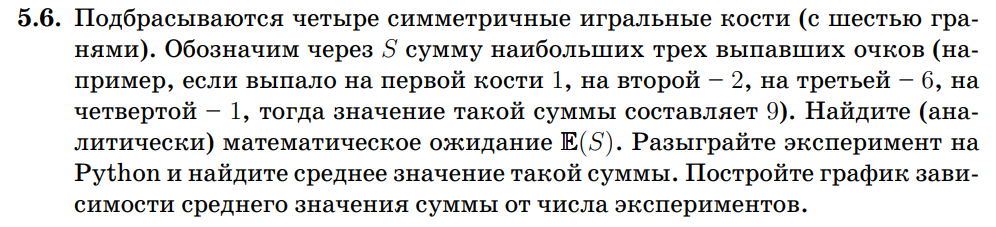

E[S] = 11.881944

Экспериментальные средние:
n =    10,000 → среднее = 12.232600
n =   100,000 → среднее = 12.241010
n = 1,000,000 → среднее = 12.242476


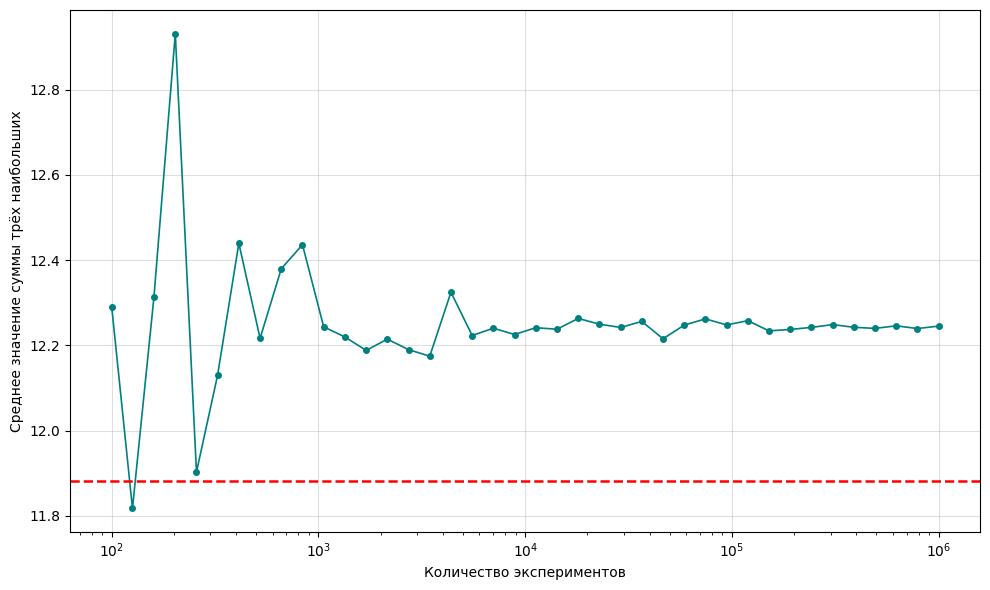

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Теоретическое значение E[S] = 4 × 3.5 − E[min из 4 костей]
E_one = 3.5
E_min = sum(k * ((7 - k)/6)**4 - ((6 - k)/6)**4 for k in range(1, 7))
E_S = 4 * E_one - E_min

print(f"E[S] = {E_S:.6f}")

# Проверка на большом числе испытаний
def experiment(n_trials):
    rolls = np.random.randint(1, 7, size=(n_trials, 4))
    top3_sum = np.sort(rolls, axis=1)[:, 1:].sum(axis=1)
    return top3_sum.mean()

# Несколько проверочных запусков
print("\nЭкспериментальные средние:")
for n in [10_000, 100_000, 1_000_000]:
    avg = experiment(n)
    print(f"n = {n:9,d} → среднее = {avg:.6f}")

# График сходимости
Ns = np.logspace(2, 6, 40, dtype=int)
means = [experiment(n) for n in Ns]

plt.figure(figsize=(10, 6))
plt.plot(Ns, means, 'o-', color='teal', markersize=4, linewidth=1.2)
plt.axhline(E_S, color='red', linestyle='--', linewidth=1.8)
plt.xscale('log')
plt.xlabel('Количество экспериментов')
plt.ylabel('Среднее значение суммы трёх наибольших')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

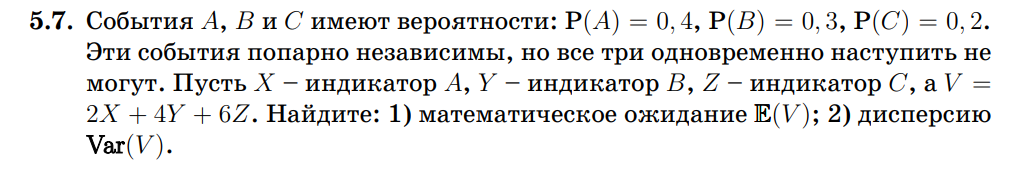

In [ ]:

PA,PB,PC = 0.4,0.3,0.2

EV = 2*PA + 4*PB + 6*PC
VarV = (2**2)*PA*(1-PA) + (4**2)*PB*(1-PB) + (6**2)*PC*(1-PC)

print("Математическое ожидание:", EV, "  Дисперсия:", VarV)


Математическое ожидание: 3.2   Дисперсия: 10.080000000000002


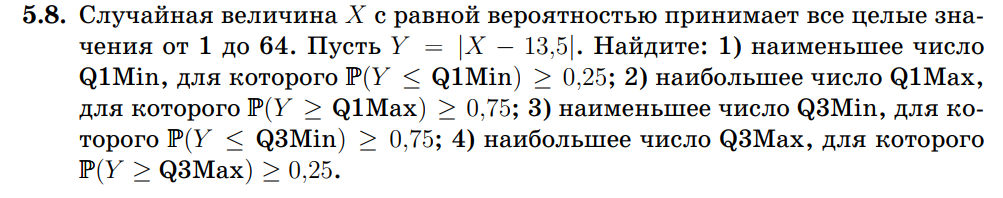

In [ ]:
import numpy as np

X = np.arange(1, 65)
p = 1 / len(X)

Y = np.abs(X - 13.5)

Y_sorted = np.sort(Y)

def P_leq(q):
    return np.sum(Y <= q) * p

def P_geq(q):
    return np.sum(Y >= q) * p

Q1Min = min(Y_sorted, key=lambda q: q if P_leq(q) >= 0.25 else np.inf)

Q1Max = max(Y_sorted, key=lambda q: q if P_geq(q) >= 0.75 else -np.inf)

Q3Min = min(Y_sorted, key=lambda q: q if P_leq(q) >= 0.75 else np.inf)

Q3Max = max(Y_sorted, key=lambda q: q if P_geq(q) >= 0.25 else -np.inf)

print("Q1min: ",Q1Min)
print("Q1max: ",Q1Max)
print("Q3min: ",Q3Min)
print("Q3max: ",Q3Max)


Q1min:  7.5
Q1max:  8.5
Q3min:  34.5
Q3max:  35.5


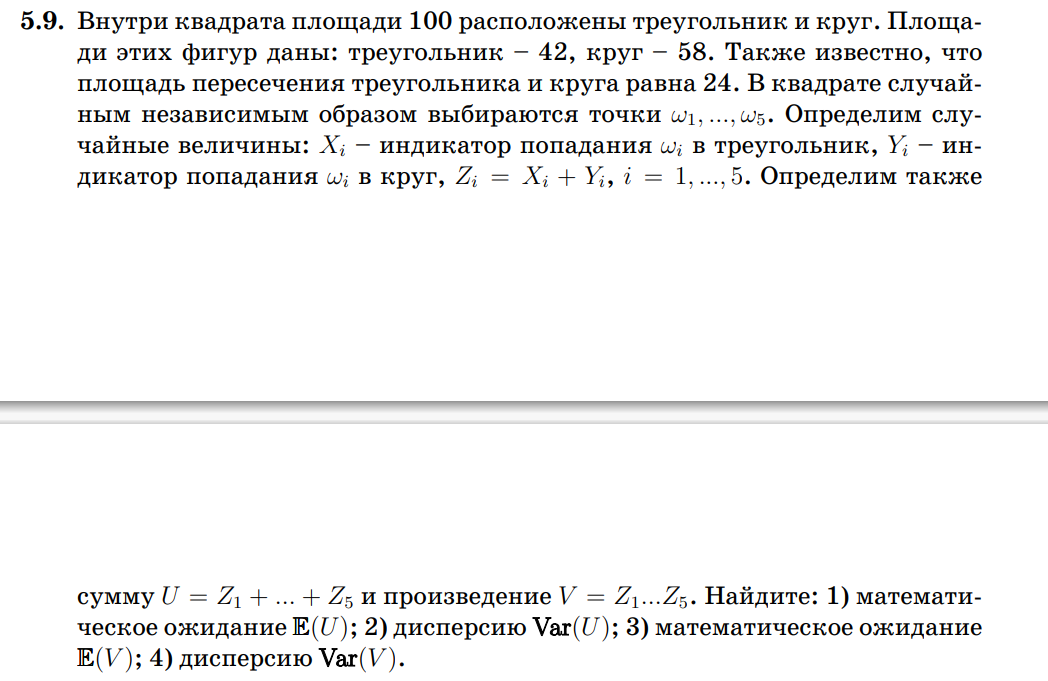

In [ ]:
from itertools import product

prob_Z = {0: 0.24, 1: 0.52, 2: 0.24}

E_Z = sum(z * p for z, p in prob_Z.items())
Var_Z = sum((z - E_Z)**2 * p for z, p in prob_Z.items())

n = 5

E_U = n * E_Z

Var_U = n * Var_Z

E_V = E_Z**n

E_Z2 = sum((z**2)*p for z, p in prob_Z.items())
E_V2 = E_Z2**n
Var_V = E_V2 - E_V**2

print(f"Математическое ожидание E(U) = {E_U:.4f}")
print(f"Дисперсия Var(U) = {Var_U:.4f}")
print(f"Математическое ожидание E(V) = {E_V:.4f}")
print(f"Дисперсия Var(V) = {Var_V:.4f}")


Математическое ожидание E(U) = 5.0000
Дисперсия Var(U) = 2.4000
Математическое ожидание E(V) = 1.0000
Дисперсия Var(V) = 6.1008


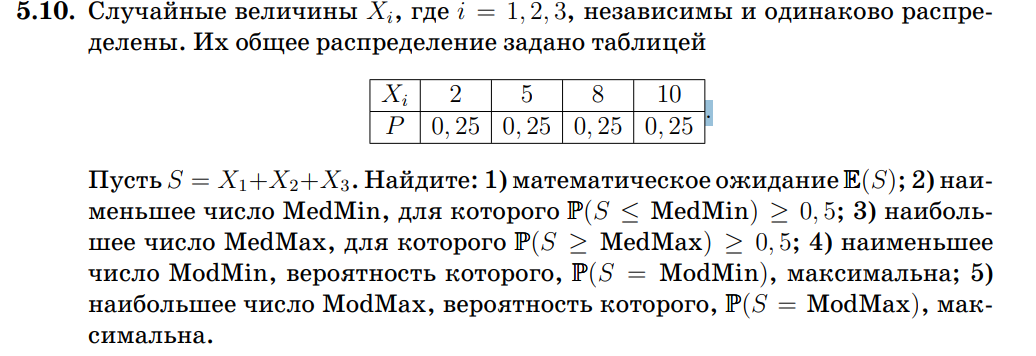

In [ ]:
from itertools import product
from collections import Counter

X_values = [2, 5, 8, 10]
prob = [0.25, 0.25, 0.25, 0.25]

combinations = list(product(X_values, repeat=3))

prob_sums = Counter()
for c in combinations:
    s = sum(c)
    p = 1
    for x in c:
        p *= 0.25
    prob_sums[s] += p

E_S = sum(s * prob_sums[s] for s in prob_sums)

sorted_sums = sorted(prob_sums.keys())
cum_prob = 0
MedMin = None
MedMax = None
for s in sorted_sums:
    cum_prob += prob_sums[s]
    if MedMin is None and cum_prob >= 0.5:
        MedMin = s
    if cum_prob <= 0.5:
        MedMax = s

max_prob = max(prob_sums.values())
ModMin = min(s for s, p in prob_sums.items() if p == max_prob)
ModMax = max(s for s, p in prob_sums.items() if p == max_prob)

print(f"E(S) = {E_S}")
print(f"MedMin = {MedMin}")
print(f"MedMax = {MedMax}")
print(f"ModMin = {ModMin}")
print(f"ModMax = {ModMax}")


E(S) = 18.75
MedMin = 18
MedMax = 18
ModMin = 20
ModMax = 20


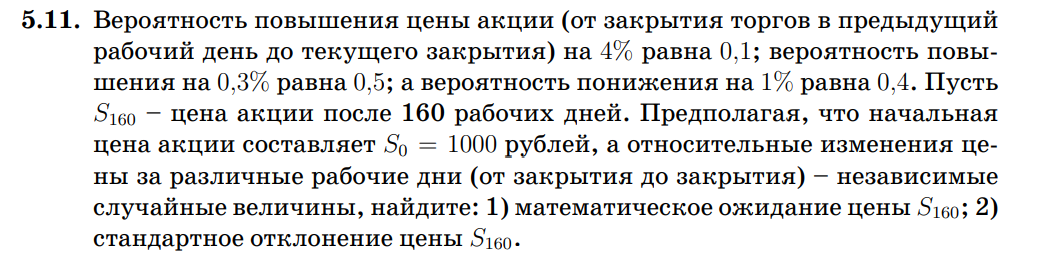

In [ ]:
S0 = 1000
n = 160

X = [0.04, 0.003, -0.01]
p = [0.1, 0.5, 0.4]

E_1plusX = sum((1 + x) * prob for x, prob in zip(X, p))
E_Sn = S0 * (E_1plusX ** n)

E_1plusX2 = sum(((1 + x)**2) * prob for x, prob in zip(X, p))
Var_Sn = S0**2 * (E_1plusX2**n - E_1plusX**(2*n))
Std_Sn = Var_Sn**0.5

print(f"Математическое ожидание E(S_160) = {E_Sn:.3f}")
print(f"Стандартное отклонение Std(S_160) = {Std_Sn:.3f}")


Математическое ожидание E(S_160) = 1271.021
Стандартное отклонение Std(S_160) = 230.142


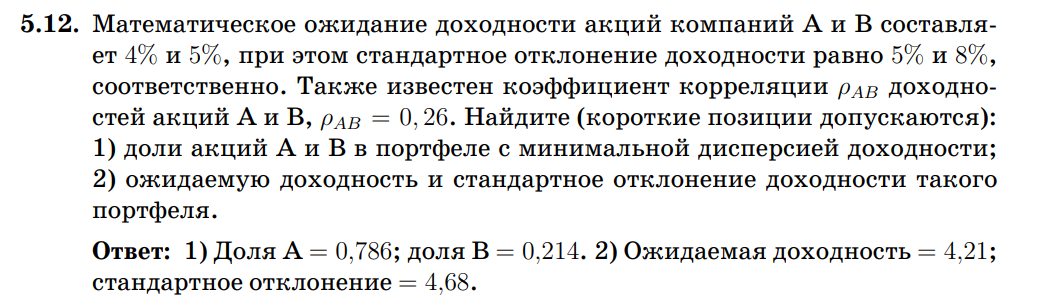

In [6]:
import numpy as np

mu = np.array([0.04, 0.05])
sigma = np.array([0.05, 0.08])
rho = 0.26

cov = np.array([
    [sigma[0]**2, rho * sigma[0] * sigma[1]],
    [rho * sigma[0] * sigma[1], sigma[1]**2]
])

ones = np.ones(2)
inv_cov = np.linalg.inv(cov)
w = inv_cov @ ones
w = w / w.sum()

expected_return = w @ mu
std_dev = np.sqrt(w @ cov @ w)

print("Минимально-рисковый портфель:")
print(f"  Доля A: {w[0]:.3f} ({w[0]*100:.1f}%)")
print(f"  Доля B: {w[1]:.3f} ({w[1]*100:.1f}%)")
print(f"  Ожидаемая доходность:   {expected_return*100:.2f}%")
print(f"  Стандартное отклонение: {std_dev*100:.2f}%")

Минимально-рисковый портфель:
  Доля A: 0.786 (78.6%)
  Доля B: 0.214 (21.4%)
  Ожидаемая доходность:   4.21%
  Стандартное отклонение: 4.68%


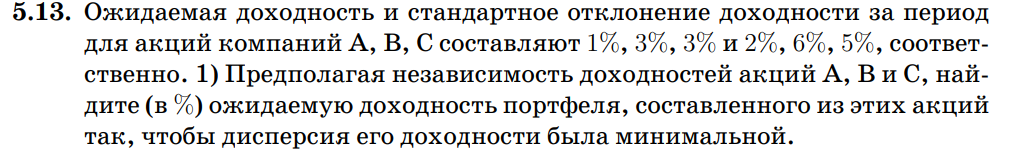

In [ ]:

mu = np.array([0.01,0.03,0.03])
sigma = np.array([0.02,0.06,0.05])

w = 1/sigma**2
w /= w.sum()

ret = w@mu
print("Доходность ", float(ret*100))


Доходность  1.4265734265734262


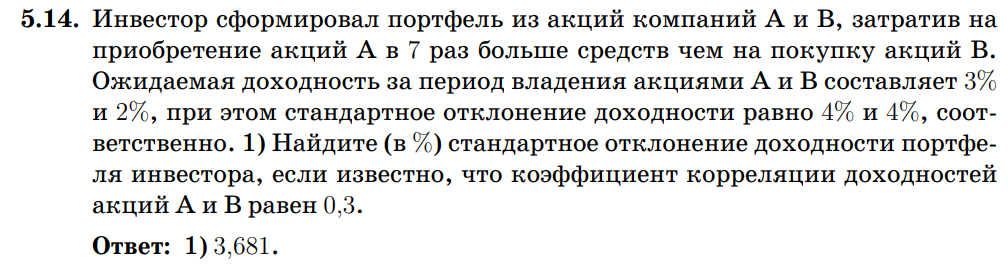

In [ ]:
import math

wA, wB = 7/8, 1/8
sigmaA = sigmaB = 0.04
rho = 0.3

var = (wA*sigmaA)**2 + (wB*sigmaB)**2 + 2*wA*wB*rho*sigmaA*sigmaB
print("Стандартное отклонение", math.sqrt(var)*100)


Стандартное отклонение 3.6810324638611926


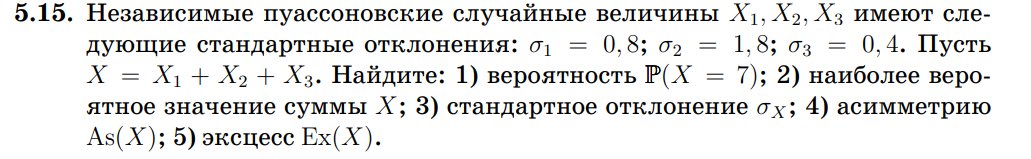

In [ ]:

lam = 0.8**2 + 1.8**2 + 0.4**2

P7 = math.exp(-lam)*lam**7/math.factorial(7)
mode = math.floor(lam)
sd = math.sqrt(lam)
skew = 1/math.sqrt(lam)
excess = 1/lam

print("Вероятность", P7)
print("Наиболее вероятное значение сумммы", mode)
print("Стандартное отклонение", sd)
print("Ассиметрия", skew)
print("Эксцесс", excess)

Вероятность 0.06133230863284511
Наиболее вероятное значение сумммы 4
Стандартное отклонение 2.009975124224178
Ассиметрия 0.49751859510499463
Эксцесс 0.24752475247524752
